In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from multi_layer_net import MultiLayerNet

In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [3]:
train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


In [5]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key] 

In [6]:
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

In [7]:
networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


In [8]:
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


===========iteration:0===========
std=0.01:2.30252434431396
Xavier:2.3174937492441736
He:2.330979303952002
===========iteration:100===========
std=0.01:2.302851958333431
Xavier:2.2499910333845166
He:1.4474343871252493
===========iteration:200===========
std=0.01:2.301533639256032
Xavier:2.0959247586220684
He:0.7304805149474397
===========iteration:300===========
std=0.01:2.3023640551901883
Xavier:1.7648099846340337
He:0.5133365637505014
===========iteration:400===========
std=0.01:2.302733559062312
Xavier:1.1391527367850836
He:0.393373502300052
===========iteration:500===========
std=0.01:2.3021307732091376
Xavier:0.7925478663648464
He:0.3127665343395199
===========iteration:600===========
std=0.01:2.301708495849625
Xavier:0.744802014133249
He:0.4331593992068036
===========iteration:700===========
std=0.01:2.300021252393921
Xavier:0.41015717721358746
He:0.21171088915478997
===========iteration:800===========
std=0.01:2.301464940803884
Xavier:0.5295484618290123
He:0.3616112733894022
===

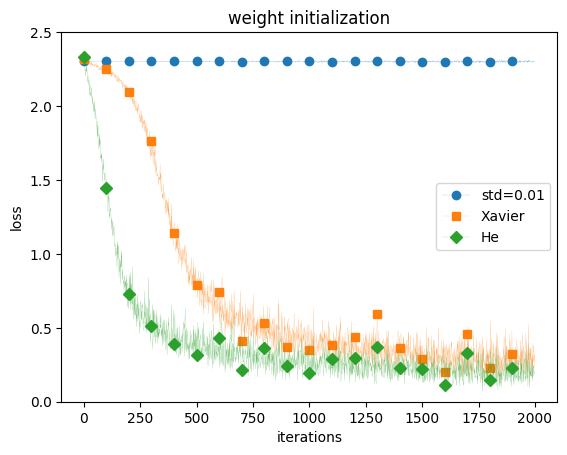

In [12]:
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, train_loss[key], marker=markers[key], markevery=100, label=key, lw=0.1)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.title("weight initialization")
plt.legend()
plt.show()